In [1]:
import numpy as np
import xarray as xr
from tqdm import tqdm #create a user-friendly feedback while script is running
from os.path import join
import pandas as pd #handle dataframes
import cc3d #connected components patterns
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as clrs
from scipy import stats
from sklearn import metrics
import cftime
import os
from pathlib import Path
import ast
import pandas as pd
import cartopy.crs as ccrs 
import cartopy.feature as cfeature 
from cartopy.io import shapereader
import geopandas as gpd
import pycountry

In [2]:
os.chdir("/home/user/These/extreme_htws_cc3d/")
directory = "Data/ERA5/t2m"

In [3]:
temp_variable = 't2m' # 't2m', 'wbgt' or 'utci'
daily_var = 'tx' # 'tg', 'tn' or 'tx' (mean, min, max), default value is 'tg'
start_year = 1975 # beginning of the studied period, default 1950
end_year = 2021 # end of the studied period, default 2021

start_year_ref = 1975 #beginning of the climatology period, default 1950
end_year_ref = 2021 #end of the climatology period, default 2021

anomaly = False #If True, the whole process is based on anomalies and not absolute values of temperature. If False, absolute values are used. Default is True

nb_days = 4 #nb of days used as a heatwave duration threshold, default value is 4
relative_threshold = True #If True, the threshold value should be a percentile and locally defined. If False, the threshold should be an absolute value. Default is True
threshold_value = 95 # If relative_threshold is True, percentile used as a threshold for heatwave occurence, value in ]0;100[, default value is 95 (consistent with default value of relative_threshold). If absolute value, expected to be a value in °C.
smooth_span = 15 #half of size of smooth span for computing climatology
distrib_window_size = 15 #size (in days) of the temporal window that is used to compute the temperature distribution (on which is based the threshold) of each calendar day, default value is 15
flex_time_span = 3 #In order to account for potential EM-DAT imprecisions, set a flexibility window of flex_time_span days, default value is 3
dust_threshold=775
nb_top_events=10 #number of top detected events to look for in the litterature

name_dict_threshold = {True : 'th', False : 'C'} #If relative threshold, value is a percentile; if absolute threshold, value is in °C

#read_directory = "/data/tmandonnet"
read_directory = "/home/user/These/extreme_htws_cc3d/Data"

write_directory = join(read_directory,f"ERA5_{temp_variable}_{daily_var}_{threshold_value}{name_dict_threshold[relative_threshold]}_{nb_days}days_flex_{flex_time_span}d_{start_year}_{end_year}_ref_{start_year_ref}_{end_year_ref}{'_anomaly'*anomaly}")
#Path(write_directory).mkdir(parents=True, exist_ok=True)

pop_file_path = join(read_directory,"GHS-POP","GHS_POP_R2023A_1975_2030_ERA5_Europe_grid.nc")
temp_file_path = join(read_directory,"ERA5",temp_variable,f"ERA5_{temp_variable}_{daily_var}_Europe_day_0.25deg_1975-2024.nc")
emdat_file_path = join(read_directory,"EM-DAT","EMDAT_Europe_Turkey-1975-2021-heatwaves.xlsx")

In [4]:
# Load EM-DAT dataset
df_emdat = pd.read_excel(join(emdat_file_path),header=0, index_col=0) 
df_emdat = df_emdat[(df_emdat['Start Month'].isin([6,7,8])) | (df_emdat['End Month'].isin([6,7,8]))] # Remove heatwaves occurring outside JJA period

In [6]:
df_emdat["ID"] = None
for idx in df_emdat.index :
    df_emdat.loc[idx,"ID"] = idx[:9]

In [9]:
df_emdat.groupby("ID").count()

,Historic,Classification Key,Disaster Group,Disaster Subgroup,Disaster Type,Disaster Subtype,External IDs,Event Name,ISO,Country,...,Reconstruction Costs ('000 US$),"Reconstruction Costs, Adjusted ('000 US$)",Insured Damage ('000 US$),"Insured Damage, Adjusted ('000 US$)",Total Damage ('000 US$),"Total Damage, Adjusted ('000 US$)",CPI,Admin Units,Entry Date,Last Update
ID,,,,,,,,,,,,,,,,,,,,,
1985-0257,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1987-0596,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1988-0298,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1988-0308,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1990-0085,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1995-0157,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1995-0363,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1996-0362,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1
1998-0204,1,1,1,1,1,1,0,0,1,1,...,0,0,0,0,0,0,1,0,1,1


In [5]:
df_emdat_undetected = pd.read_csv(join(write_directory,"df_emdat_overlap.csv"),header=0, index_col=0)
df_emdat_undetected = df_emdat_undetected[df_emdat_undetected["overlap CC3D"]=='[]']

# Plotting undetected EM-DAT heatwaves

In [7]:
df_emdat_undetected = pd.read_csv(join(write_directory,"df_emdat_overlap.csv"),header=0, index_col=0)
country_dict = {'Albania':'Albania', 'Austria':'Austria', 'Belarus':'Belarus',
                    'Belgium':'Belgium', 'Bosnia and Herzegovina':'Bosnia_and_Herzegovina',
                    'Bulgaria':'Bulgaria', 'Croatia':'Croatia', 'Cyprus':'Cyprus', 
                    'Czechia':'Czechia', 'Denmark':'Denmark', 'Estonia':'Estonia', 
                    'Finland':'Finland', 'France':'France', 'Germany':'Germany', 'Greece':'Greece', 
                    'Hungary':'Hungary', 'Iceland':'Iceland', 'Ireland':'Ireland', 
                    'Italy':'Italy', 'Latvia':'Latvia', 'Lithuania':'Lithuania',
                    'Luxembourg':'Luxembourg', 'Montenegro':'Montenegro',
                    'North Macedonia':'Macedonia',
                    'Moldova':'Moldova', 'Netherlands':'Netherlands', 'Norway':'Norway', 
                    'Poland':'Poland','Portugal':'Portugal', 'Romania':'Romania',
                    'Russian Federation':'Russia', 'Serbia':'Serbia', 
                    'Serbia Montenegro':'Serbia', # The corresponding heatwave happened in Serbia, cf 'Location' data of EM-DAT
                    'Slovakia':'Slovakia', 'Slovenia':'Slovenia', 'Spain':'Spain', 'Sweden':'Sweden',
                    'Switzerland':'Switzerland', 'Türkiye':'Turkey',
                    'United Kingdom':'United_Kingdom',
                    'Ukraine':'Ukraine','Yugoslavia':'Serbia'} # The corresponding heatwave happened in Serbia, cf 'Location' data of EM-DAT

resolution_cartopy = '10m'
category = 'cultural'
name = 'admin_0_countries'
shpfilename = shapereader.natural_earth(resolution_cartopy, category, name)
df_countries = gpd.read_file(shpfilename)

df_emdat_undetected = df_emdat_undetected[df_emdat_undetected['overlap CC3D']=='[]']
df_emdat_undetected["Heatwave ID"] = None
for idx in df_emdat_undetected.index :
    df_emdat_undetected.loc[idx,"Heatwave ID"] = idx[:-4]
    if df_emdat_undetected.loc[idx, "Country"] == "United Kingdom of Great Britain and Northern Ireland" :
        df_emdat_undetected.loc[idx, "Country"] = "United Kingdom"
    elif df_emdat_undetected.loc[idx, "Country"] == "Netherlands (Kingdom of the)" :
        df_emdat_undetected.loc[idx, "Country"] = "Netherlands"
list_htws_id = np.unique(df_emdat_undetected["Heatwave ID"])

df_emdat_grouped = pd.DataFrame(index=list_htws_id,columns=['Total Deaths','Affected Countries (Total Deaths)','Most impactful'])
htw_most_impact_df = pd.DataFrame(index=list_htws_id,columns=['Heatwave ID','Country','Total Deaths'])
for htw_ID in df_emdat_grouped.index :
    df_emdat_grouped.loc[htw_ID,'Total Deaths'] = int((df_emdat_undetected[df_emdat_undetected['Heatwave ID']==htw_ID])['Total Deaths'].sum())
    df_emdat_grouped.loc[htw_ID,'Most impactful'] = (df_emdat_undetected[df_emdat_undetected['Heatwave ID']==htw_ID])['Total Deaths'].idxmax(skipna=True)
    l1 = (df_emdat_undetected[df_emdat_undetected['Heatwave ID']==htw_ID])['Country'].tolist()
    l2 = [int (i) for i in (df_emdat_undetected[df_emdat_undetected['Heatwave ID']==htw_ID].fillna(0))['Total Deaths'].tolist()]
    list_countries_deaths = [f"{i} ({str(j)})" for (i,j) in zip(l1,l2)]
    if len(list_countries_deaths) > 3 :
        list_countries_deaths[3]='\\\\'+list_countries_deaths[3]
    df_emdat_grouped.loc[htw_ID,'Affected Countries (Total Deaths)'] = ', '.join(list_countries_deaths)
df_emdat_grouped = df_emdat_grouped.sort_values(by='Total Deaths',ascending=False)

ds_temp = xr.open_dataset(join(temp_file_path), engine='netcdf4')
da_temp = getattr(ds_temp,temp_variable)
da_temp = da_temp.convert_calendar("noleap") # Drop 29 Feb
#da_threshold = xr.open_dataarray(join(write_directory,f"distrib_threshold_{threshold_value}.nc"),engine='netcdf4')

# Keep only JJA values; labels and HWMId are already JJA-only
da_temp = da_temp.sel(time=(da_temp.time.dt.year>=start_year) & (da_temp.time.dt.year<=end_year))
da_temp = da_temp.sel(time = (da_temp.time.dt.season=='JJA'))
#mask = (da_threshold.dayofyear>=152) & (da_threshold.dayofyear<=243) # dayofyear ranges from 1 to 365 ; 152 is June 1st, 243 is August 31st
#da_threshold = da_threshold.sel(dayofyear=mask)


climatology = xr.open_dataarray(join(write_directory,f"climatology_smooth_span_{smooth_span}d.nc"), engine='netcdf4')
# Keep only JJA values
mask = (climatology.dayofyear>=152) & (climatology.dayofyear<=243)
climatology = climatology.sel(dayofyear=mask)
#da_temp = da_temp - climatology.data

for year in range(end_year-start_year+1) : # Compute temperature exceedance relative to the threshold, iterate over years (92 JJA days per year)
    da_temp[year*92:(year+1)*92,:,:] = da_temp[year*92:(year+1)*92,:,:] - climatology.data

for i in range(np.min([3,len(df_emdat_grouped)])):
    country_list = df_emdat_grouped.iloc[i,1].split(", ")
    country_list[0] = "\\textbf{"+country_list[0]+"}"
    df_emdat_grouped.iloc[i,1] = ', '.join(country_list)

/tmp/ipykernel_2904/2720721988.py:40: FutureWarning: The behavior of Series.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df_emdat_grouped.loc[htw_ID,'Most impactful'] = (df_emdat_undetected[df_emdat_undetected['Heatwave ID']==htw_ID])['Total Deaths'].idxmax(skipna=True)


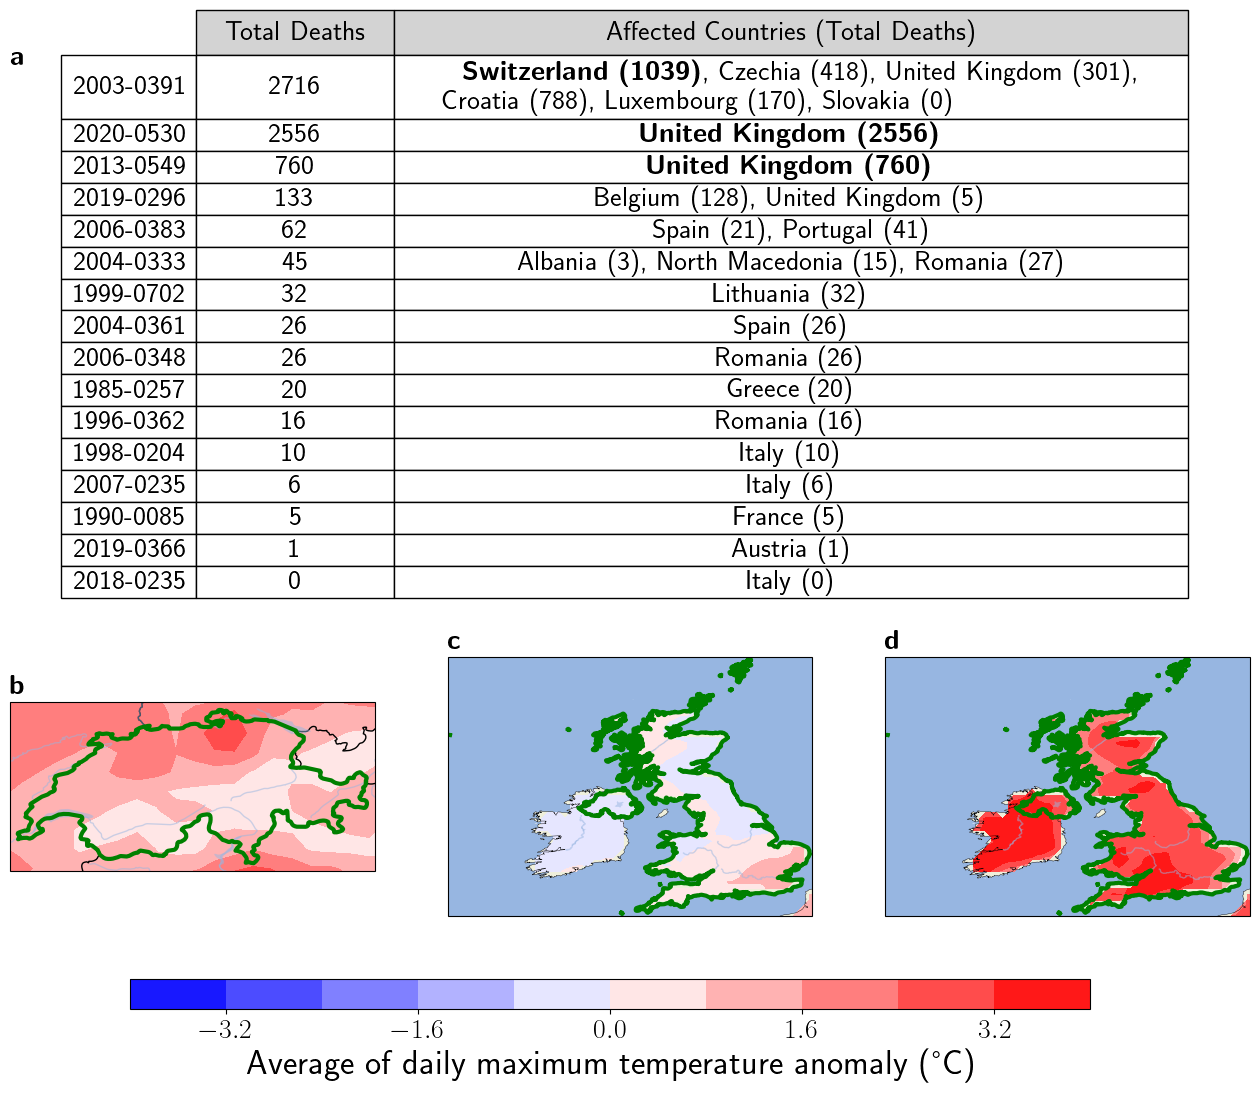

In [ ]:
import matplotlib as mpl
mpl.rcParams.update(mpl.rcParamsDefault)
land_mask = xr.open_dataset(join(read_directory,'ERA5','Mask',f"Mask_Europe_land_only_ERA5_0.25deg.nc"),engine='netcdf4').mask
if len(df_emdat_grouped)>=3 :
    plt.close()
    plt.rcParams['text.usetex'] = True
    fig_subplot = plt.figure(figsize=(16,12))
    ax1=fig_subplot.add_subplot(234,projection=ccrs.PlateCarree()).set_title('\\textbf{b}',loc='left',size=20)
    ax2=fig_subplot.add_subplot(235,projection=ccrs.PlateCarree()).set_title('\\textbf{c}',loc='left',size=20)
    ax3=fig_subplot.add_subplot(236,projection=ccrs.PlateCarree()).set_title('\\textbf{d}',loc='left',size=20)
    ax4=fig_subplot.add_subplot(211).set_title('\\textbf{a}',loc='left',size=20)
    min_val=0
    max_val=0
    plotted_var = [[]]*3
    sub_df = df_emdat_grouped[["Total Deaths","Affected Countries (Total Deaths)"]]
    for ax_count in range(3) :
        htw_ID = df_emdat_grouped.iloc[ax_count,2] # Get heatwave identifier to look for corresponding EM-DAT information
        country = df_emdat_undetected.loc[htw_ID,'Country']
        mask_country = xr.open_dataset(join(read_directory,"ERA5","Mask",f"Mask_{country_dict[country]}_ERA5_0.25deg.nc"),engine='netcdf4').mask
        mask_country['lat'] = da_temp.lat # Fix broken latitude
        mask_country['lon'] = da_temp.lon # Fix broken longitude
        year_event = int(df_emdat.loc[htw_ID,'Start Year'])
        if np.isnan(df_emdat.loc[htw_ID,'Start Day']) : # If Start Day is not recorded, start searching at 1st day of the month
            date_beg = pd.Timestamp(year_event, int(df_emdat.loc[htw_ID,'Start Month']), 1)
        else : # Otherwise, take recorded day and add flex_time_span to 
            date_beg = pd.Timestamp(year_event, int(df_emdat.loc[htw_ID,'Start Month']), int(df_emdat.loc[htw_ID,'Start Day'])) - pd.DateOffset(days=flex_time_span)

        if np.isnan(df_emdat.loc[htw_ID,'End Day']) : # If End Day is not recorded, keep searching until last day of the month
            date_end = pd.Timestamp(year_event, int(df_emdat.loc[htw_ID,'End Month']), 1)
            date_end = pd.offsets.MonthEnd().rollforward(date_end)
        else : # Otherwise, take recorded day and add flex_time_span
            date_end = pd.Timestamp(year_event, int(df_emdat.loc[htw_ID,'End Month']), int(df_emdat.loc[htw_ID,'End Day'])) + pd.DateOffset(days=flex_time_span)

        date_beg = cftime.DatetimeNoLeap(date_beg.year, date_beg.month, date_beg.day)
        date_end = cftime.DatetimeNoLeap(date_end.year, date_end.month, date_end.day)

        da_temp_event = da_temp.sel(time=slice(date_beg,date_end)) # Keep only values matching the period of EM-DAT event
        da_temp_event = da_temp_event.where(land_mask.data==0,drop=False)
        plotted_var[ax_count] = da_temp_event.mean(dim="time")
        da_temp_event = da_temp_event.where(mask_country==0,drop=False).mean(dim="time")
        min_val = min(min_val,min(np.floor(-np.abs(da_temp_event.min().data)),np.floor(-np.abs(da_temp_event.max().data))))
        max_val = max(max_val,max(np.ceil(np.abs(da_temp_event.min().data)),np.ceil(np.abs(da_temp_event.max().data))))
        
    the_levels=[0]*11#nb of color categories + 1
    for k in range(len(the_levels)):
        the_levels[k]=min_val+k*(max_val-min_val)/(len(the_levels)-1)
    ax_count=0 
    for ax in [ax1.axes,ax2.axes,ax3.axes] :
        htw_ID = df_emdat_grouped.iloc[ax_count,2] # Get heatwave identifier to look for corresponding EM-DAT information
        country = df_emdat_undetected.loc[htw_ID,'Country']
        CS1 = ax.contourf(da_temp.lon,da_temp.lat,plotted_var[ax_count],cmap='bwr',transform=ccrs.PlateCarree(), levels=the_levels)
        poly = df_countries.loc[df_countries['ADMIN'] == country]['geometry'].values[0]
        try :
            ax.plot(*poly.exterior.xy,'green',linewidth=3)
        except :#in case the country is not Polygon but MultiPolygon
            for geom in poly.geoms :
                ax.plot(*geom.exterior.xy,'green',linewidth=3)
        ax.set_extent([poly.bounds[0]-0.1,poly.bounds[2]+0.1,poly.bounds[1]-0.1,poly.bounds[3]+0.1])
        ax.add_feature(cfeature.BORDERS)
        ax.add_feature(cfeature.LAND)
        ax.add_feature(cfeature.OCEAN)
        ax.add_feature(cfeature.COASTLINE,linewidth=0.3)
        ax.add_feature(cfeature.LAKES, alpha=0.5)
        ax.add_feature(cfeature.RIVERS, alpha=0.5)
        ax_count+=1
    cax = plt.axes([0.2, 0.1, 0.6, 0.025])
    cbar = fig_subplot.colorbar(CS1,cax=cax,orientation='horizontal')
    cbar.set_label('Average of daily maximum temperature anomaly (°C)', rotation=0, size=25)
    cbar.ax.tick_params(labelsize=20)
    
    table = ax4.axes.table(cellText=sub_df.values,
            rowLabels=sub_df.index,
            colLabels=sub_df.columns,bbox=[0.15,-0.25,0.8,1.4],cellLoc='center',colWidths=[0.15,0.6])
    cellDict = table.get_celld()
    for i in range(0,len(sub_df.columns)):
        cellDict[(0,i)].set_height(.1)
        cellDict[(1,i)].set_height(4.2/30)
        for j in range(2,len(sub_df.values)+1):
            cellDict[(j,i)].set_height(2.1/30)
            if i==0 :
                cellDict[(j,-1)].set_height(2.1/30)
    cellDict[(0, 0)].set_facecolor("lightgray")
    cellDict[(0, 1)].set_facecolor("lightgray")
    cellDict[(1,-1)].set_height(4.2/30)
    ax4.axes.set_axis_off()
    table.auto_set_font_size(False)
    table.set_fontsize(20)
    plt.savefig(join(write_directory,"figs","Undetected.pdf"),dpi=1200)
    plt.show()

# Trends

In [10]:
temp_variable = 't2m' # 't2m', 'wbgt' or 'utci'
daily_var = 'tx' # 'tg', 'tn' or 'tx' (mean, min, max), default value is 'tg'
start_year = 1975 # beginning of the studied period, default 1950
end_year = 2024 # end of the studied period, default 2021

start_year_ref = 1975 #beginning of the climatology period, default 1950
end_year_ref = 2021 #end of the climatology period, default 2021

anomaly = False #If True, the whole process is based on anomalies and not absolute values of temperature. If False, absolute values are used. Default is True

nb_days = 4 #nb of days used as a heatwave duration threshold, default value is 4
relative_threshold = True #If True, the threshold value should be a percentile and locally defined. If False, the threshold should be an absolute value. Default is True
threshold_value = 95 # If relative_threshold is True, percentile used as a threshold for heatwave occurence, value in ]0;100[, default value is 95 (consistent with default value of relative_threshold). If absolute value, expected to be a value in °C.
smooth_span = 15 #half of size of smooth span for computing climatology
distrib_window_size = 15 #size (in days) of the temporal window that is used to compute the temperature distribution (on which is based the threshold) of each calendar day, default value is 15
flex_time_span = 3 #In order to account for potential EM-DAT imprecisions, set a flexibility window of flex_time_span days, default value is 3
dust_threshold=775
nb_top_events=10 #number of top detected events to look for in the litterature

name_dict_threshold = {True : 'th', False : 'C'} #If relative threshold, value is a percentile; if absolute threshold, value is in °C

#read_directory = "/data/tmandonnet"
read_directory = "/home/user/These/extreme_htws_cc3d/Data"

write_directory = join(read_directory,f"ERA5_{temp_variable}_{daily_var}_{threshold_value}{name_dict_threshold[relative_threshold]}_{nb_days}days_flex_{flex_time_span}d_{start_year}_{end_year}_ref_{start_year_ref}_{end_year_ref}{'_anomaly'*anomaly}")
#Path(write_directory).mkdir(parents=True, exist_ok=True)

pop_file_path = join(read_directory,"GHS-POP","GHS_POP_R2023A_1975_2030_ERA5_Europe_grid.nc")
temp_file_path = join(read_directory,"ERA5",temp_variable,f"ERA5_{temp_variable}_{daily_var}_Europe_day_0.25deg_1975-2024.nc")
emdat_file_path = join(read_directory,"EM-DAT","EMDAT_Europe_Turkey-1975-2021-heatwaves.xlsx")

In [ ]:
land_mask = xr.open_dataset(join(read_directory,'ERA5','Mask',f"Mask_Europe_land_only_ERA5_0.25deg.nc"),engine='netcdf4').mask
ds_cell_area = xr.open_dataset(join(read_directory,"ERA5","ERA5_Europe_cellarea.nc"),engine='netcdf4') # Area of each grid cell, in m²
da_cell_area = ds_cell_area.cell_area/1e6 # Load DataArray and convert to km²
area_Europe = da_cell_area.where(land_mask==0).sum().data
ds_pop = xr.open_dataset(join(pop_file_path), engine='netcdf4') # Population count, need to convert to density
da_pop = ds_pop.Band1*1000 # Data is in thousands of people and we want the number of people in units
pop_Europe = da_pop.where(land_mask==0).sum(dim=("lat","lon"))

In [ ]:
# Load heatwaves indices database
df_htws = pd.read_csv(join(write_directory,f"df_htws_step2.csv"),header=0, index_col=0)

df_htws["Exposed_population (relative)"] = None
for i in df_htws.index :
    df_htws.loc[i,"Exposed_population (relative)"] = np.round(100 * df_htws.loc[i,"Exposed_population"]/pop_Europe.sel(time=(pop_Europe.time.dt.year==df_htws.loc[i,"Year"])).data[0],4)

# Indices on which we want to compute trends
htw_indices = ['Frequency','Intensity','Max','Spatial extent','Duration','HWMId_sum','Exposed_population','Exposed_population (relative)','HWMId_pop']
# We want to compute trends for 1975-2024 but also sub-period 1975-2014
sub_df_htws = df_htws[df_htws["Year"]<=2014]
arrays = [
    ["1975-2014", "1975-2014", "1975-2014", "1975-2024", "1975-2024","trend variation (%)"],
    ["unit", "\beta", "significance", "\beta", "significance","% of \beta"]
]
tuples = list(zip(*arrays))
columns = pd.MultiIndex.from_tuples(tuples, names=["period", ""])
df_trends = pd.DataFrame(index=htw_indices,columns=columns)

# Create dictionary to handle units of different index trends
unit_dict = {"Frequency":"Events/decade", "Intensity":"°C/decade", "Max":"°C/decade", "Spatial extent":"% of Europe area/decade", "Duration":"days/decade", "HWMId_sum":"% of typical event/decade",
                "Exposed_population":"10^6 ppl/decade", "Exposed_population (relative)":"% of European population/decade",
                 "HWMId_pop":"% of typical event/decade"}

# Create functions to compute relevant trends
def per_decade(x,index):
    return x*10
def percent_typical(x,index,df=df_htws):
    df = df[df["Year"]<=2014]
    return 10*100*x/df[index].mean()
def percent_Europe(x,indexarea_Europe=area_Europe):
    return 10*100*x/area_Europe
def million_per_decade(x,index):
    return 10*x/1e6
# Create dictionary to match index with function
func_dict = {"Frequency":per_decade, "Intensity":per_decade, "Max":per_decade, "Spatial extent":percent_Europe, "Duration":per_decade, 
                "HWMId_sum":percent_typical,
                "Exposed_population":million_per_decade,"Exposed_population (relative)":per_decade,
                "HWMId_pop":percent_typical}

# Compute trends for frequency
index = "Frequency"
correlation = stats.linregress(sub_df_htws.groupby("Year").count()["Start Date"].index,sub_df_htws.groupby("Year").count()["Start Date"].values,nan_policy='omit')
df_trends.loc[index,("1975-2014","\beta")] = np.round(func_dict[index](correlation.slope,index),2)
df_trends.loc[index,("1975-2014","unit")] = unit_dict[index]
df_trends.loc[index,("1975-2014","significance")] = ''+'*'*(float(correlation.pvalue)<0.05)+'*'*(float(correlation.pvalue)<0.01)+'*'*(float(correlation.pvalue)<0.001)

correlation = stats.linregress(df_htws.groupby("Year").count()["Start Date"].index,df_htws.groupby("Year").count()["Start Date"].values,nan_policy='omit')
df_trends.loc[index,("1975-2024","\beta")] = np.round(func_dict[index](correlation.slope,index),2)
df_trends.loc[index,("1975-2024","significance")] = ''+'*'*(float(correlation.pvalue)<0.05)+'*'*(float(correlation.pvalue)<0.01)+'*'*(float(correlation.pvalue)<0.001)
df_trends.loc[index,("trend variation (%)","% of \beta")] = np.round(100*(df_trends.loc[index,("1975-2024","\beta")] - df_trends.loc[index,("1975-2014","\beta")])/df_trends.loc[index,("1975-2014","\beta")],2)

# Compute trends for all other indices
for index in df_trends.index[1:] :
    col = "1975-2014"
    correlation = stats.linregress(sub_df_htws.loc[:,'Year'], sub_df_htws.loc[:,index].astype("float"), nan_policy='omit')
    df_trends.loc[index,("1975-2014","\beta")] = np.round(func_dict[index](correlation.slope,index),2)
    df_trends.loc[index,("1975-2014","unit")] = unit_dict[index]

    df_trends.loc[index,("1975-2014","significance")] = ''+'*'*(float(correlation.pvalue)<0.05)+'*'*(float(correlation.pvalue)<0.01)+'*'*(float(correlation.pvalue)<0.001)

    col = "1975-2024"
    correlation = stats.linregress(df_htws.loc[:,'Year'], df_htws.loc[:,index].astype("float"), nan_policy='omit')
    df_trends.loc[index,("1975-2024","\beta")] = np.round(func_dict[index](correlation.slope,index),2)
    df_trends.loc[index,("1975-2024","significance")] = ''+'*'*(float(correlation.pvalue)<0.05)+'*'*(float(correlation.pvalue)<0.01)+'*'*(float(correlation.pvalue)<0.001)
    df_trends.loc[index,("trend variation (%)","% of \beta")] = np.round(100*(df_trends.loc[index,("1975-2024","\beta")] - df_trends.loc[index,("1975-2014","\beta")])/df_trends.loc[index,("1975-2014","\beta")],2)


Intensity
Max
Spatial extent
Duration
HWMId_sum
Affected population
Affected population (relative)
HWMId_pop


In [13]:
df_trends#.to_csv


period                                                1975-2014         \
                                                           unit   eta   
Frequency                                         Events/decade   0.96   
Intensity                                             °C/decade  -0.02   
Max                                                   °C/decade   0.13   
Spatial extent                          % of Europe area/decade    1.3   
Duration                                            days/decade   0.72   
HWMId_sum                             % of typical event/decade  45.28   
Affected population                             10^6 ppl/decade   8.53   
Affected population (relative)  % of European population/decade   0.99   
HWMId_pop                             % of typical event/decade  39.04   

period                                      1975-2024               \
                               significance      eta significance   
Frequency                               ***      1.03          ***   
Intensity                                        0.04                
Max                                              0.21           **   
Spatial extent                           **      1.32          ***   
Duration                                         1.59          ***   
HWMId_sum                                       35.14            *   
Affected population                       *     11.24          ***   
Affected population (relative)            *      1.32          ***   
HWMId_pop                                       37.76            *   

period                         trend variation (%)  
                                         % of eta  
Frequency                                     7.29  
Intensity                                   -300.0  
Max                                          61.54  
Spatial extent                                1.54  
Duration                                    120.83  
HWMId_sum                                   -22.39  
Affected population                          31.77  
Affected population (relative)               33.33  
HWMId_pop                                    -3.28